# 에브리타임 크롤링 데이터 분석

## 데이터 업로드

In [ ]:
!pip install --upgrade konlpy

In [ ]:
# Colab에서 Mecab 실행 위해 필요
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab_light_220429.sh

fatal: destination path 'Mecab-ko-for-Google-Colab' already exists and is not an empty directory.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2025-05-07 07:39:06--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.24, 104.192.142.26, 104.192.142.25, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.24|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://bbuseruploads.s3.amazonaws.com/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz?response-content-disposition=attachment%3B%20filename%3D%22mecab-0.996-ko-0.9.2.tar.gz%22&response-content-encoding=None&AWSAccessKeyId=[REDACTED]&Signature=[REDACTED]&x-amz-security-token=[REDACTED]&Expires=1746605346 [following]
--2025-05-07 07:39:06--  https://bbuseruploads.s3.ama

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import re
from datetime import datetime, timedelta
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive''''''''''
from konlpy.tag import Okt, Mecab
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [ ]:
fm.findSystemFonts()
!apt-get update -qq
!apt-get install fonts-nanum* -qq
sys_font=fm.findSystemFonts()
nanum_font = [f for f in sys_font if 'Nanum' in f]
nanum_font
fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic')
fm.fontManager.ttflist.insert(0, fe)
plt.rcParams["font.family"] = 'NanumGothic'
mpl.rcParams['axes.unicode_minus'] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/구해줘! 잡스/everytime_df.csv", encoding='utf-8')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/구해줘! 잡스/everytime_df.csv'

In [ ]:
df.shape

(2020, 17)

## 데이터 전처리

### 날짜

In [ ]:
def parse_date(s):
    now = datetime.now()
    s = str(s).strip()

    # "n분 전" 패턴
    m = re.match(r'(\d+)\s*분 전', s)
    if m:
        return now - timedelta(minutes=int(m.group(1)))

    # "MM/DD HH:MM" 패턴
    m = re.match(r'(\d{1,2})/(\d{1,2})\s+(\d{1,2}):(\d{2})', s)
    if m:
        month, day, hour, minute = map(int, m.groups())
        return datetime(now.year, month, day, hour, minute)

    # 그 외는 변환 불가
    return pd.NaT

In [ ]:
df['parsed_date'] = df['date'].apply(parse_date)
df['parsed_date'].head()

,parsed_date
0,2025-05-07 07:38:14.930340
1,2025-05-07 07:01:14.930550
2,2025-05-01 19:29:00.000000
3,2025-05-01 19:25:00.000000
4,2025-05-01 19:05:00.000000


In [ ]:
df['year']   = df['parsed_date'].dt.year
df['month']  = df['parsed_date'].dt.month
df['day']    = df['parsed_date'].dt.day
df['hour']   = df['parsed_date'].dt.hour
print(df[['parsed_date','year','month','day','hour']].head())

                 parsed_date  year  month  day  hour
0 2025-05-07 07:38:14.930340  2025      5    7     7
1 2025-05-07 07:01:14.930550  2025      5    7     7
2 2025-05-01 19:29:00.000000  2025      5    1    19
3 2025-05-01 19:25:00.000000  2025      5    1    19
4 2025-05-01 19:05:00.000000  2025      5    1    19


In [ ]:
df_tail = df.iloc[2270:].copy()
df_tail.head()

,content,comment,like,comment_count,scrap,date,parsed_date,year,month,day,hour,clean_text,morphs,tokens,processed,emotion_text,topic_text


In [ ]:
df_tail['parsed_date'] = pd.to_datetime(df_tail['date'], errors='coerce')
df_tail['year']   = df_tail['parsed_date'].dt.year
df_tail['month']  = df_tail['parsed_date'].dt.month
df_tail['day']    = df_tail['parsed_date'].dt.day
df_tail['hour']   = df_tail['parsed_date'].dt.hour
print(df_tail[['parsed_date','year','month','day','hour']].head())

Empty DataFrame
Columns: [parsed_date, year, month, day, hour]
Index: []


In [ ]:
df.update(df_tail[['year', 'month', 'day', 'hour']])
print(df[['parsed_date','year','month','day','hour']].tail())

             parsed_date  year  month  day  hour
2015 2025-01-23 22:56:00  2025      1   23    22
2016 2025-01-23 22:23:00  2025      1   23    22
2017 2025-01-23 17:57:00  2025      1   23    17
2018 2025-01-23 17:30:00  2025      1   23    17
2019 2025-01-23 17:06:00  2025      1   23    17


### 텍스트

In [ ]:
# 텍스트 클리닝
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text) # HTML 태그 제거
    text = re.sub(r'http\S+', ' ', text) # URL 제거
    text = re.sub(r'[^가-힣a-zA-Z0-9\s]', ' ', text) # 특수문자 제거
    text = re.sub(r'\s+', ' ', text).strip() # 다중 공백 -> 단일 공백
    return text

df['clean_text'] = df['content'].apply(clean_text)

In [ ]:
df['clean_text'].head()

,clean_text
0,지사트 결과 예상 발표일이 언제쯤인가요
1,추천채용 지원현황에 추천이라뜨면 추천된건가요 그리고 서류전형만 우대인건지도 궁금합니...
2,취준스터디 같이 할 사람 각잡고 취준하기엔 한계가 있다보니 컴활자격증부터 취득하려는...
3,경영 21질문 재무 학회 하나하고 이제 인턴하려는데 이 루트 밟으면 취업 되는거 맞...
4,막학기인데 최종졸업 학부 성적 막학기고 아직 졸업 안했는데 입사지원서에 최종졸업 학...


In [ ]:
# 형태소 분석 및 어간 추출 -> OKt
okt = Okt()
df['morphs'] = df['clean_text'].apply(lambda x: okt.morphs(x, stem=True))

In [ ]:
df['morphs'].head()

,morphs
0,"[지사, 트, 결과, 예상, 발표, 일이, 언제, 쯤, 인가요]"
1,"[추천, 채용, 지, 원, 현황, 에, 추천, 이라, 뜨다, 추천, 되다, 가요, ..."
2,"[취준, 스터디, 같이, 하다, 사람, 각, 잡고, 취준, 하다, 한계, 가, 있다..."
3,"[경영, 21, 질문, 재무, 학회, 하나, 하고, 이제, 인턴, 하다, 이, 루트..."
4,"[막, 학기, 인데, 최종, 졸업, 학부, 성적, 막, 학기, 고, 아직, 졸업, ..."


In [ ]:
sentence = "요즘 취업 준비하느라 너무 힘들어요."
print(okt.morphs(sentence))
print(okt.pos(sentence))

['요즘', '취업', '준비', '하느라', '너무', '힘들어요', '.']
[('요즘', 'Noun'), ('취업', 'Noun'), ('준비', 'Noun'), ('하느라', 'Verb'), ('너무', 'Adverb'), ('힘들어요', 'Adjective'), ('.', 'Punctuation')]


In [ ]:
# 형태소 분석 및 어간 추출 -> Mecab
mecab = Mecab()
df['morphs'] = df['clean_text'].apply(lambda x: mecab.morphs(x))

In [ ]:
df['morphs'].head()

,morphs
0,"[지사, 트, 결과, 예상, 발표, 일, 이, 언제, 쯤, 인가요]"
1,"[추천, 채용, 지원, 현황, 에, 추천, 이, 라, 뜨, 면, 추천, 된, 건가요..."
2,"[취, 준, 스터디, 같이, 할, 사람, 각, 잡, 고, 취, 준하, 기, 엔, 한..."
3,"[경영, 21, 질문, 재무, 학회, 하나, 하고, 이제, 인턴, 하, 려는데, 이..."
4,"[막, 학기, 인데, 최종, 졸업, 학부, 성적, 막, 학기, 고, 아직, 졸업, ..."


In [ ]:
sentence = "요즘 취업 준비하느라 너무 힘들어요."
print(mecab.morphs(sentence))
print(mecab.pos(sentence))

['요즘', '취업', '준비', '하', '느라', '너무', '힘들', '어요', '.']
[('요즘', 'MAG'), ('취업', 'NNG'), ('준비', 'NNG'), ('하', 'XSV'), ('느라', 'EC'), ('너무', 'MAG'), ('힘들', 'VA'), ('어요', 'EF'), ('.', 'SF')]


| 태그  | 품사 (한글)                   | 설명                                                |
|------|------------------------------|-----------------------------------------------------|
| NNG  | 일반 명사 (Common Noun)       | 사물·사람·개념 등을 가리키는 명사                     |
| MAG  | 일반 부사 (General Adverb)    | 정도·방법·시간 등을 수식하는 부사                     |
| XSV  | 동사 파생 접미사 (Verb Suffix) | 동사를 만드는 접미사 (“하”-에 붙어 “하다” 생성)       |
| EC   | 연결 어미 (Conjunctive Ending)| 어미 중 다음 구문과 이어질 때 쓰이는 형태             |
| EF   | 종결 어미 (Final Ending)      | 문장을 마무리할 때 쓰이는 어미 (“-어요”, “-다” 등)    |
| VA   | 형용사 어간 (Adjective Stem)   | 형용사의 핵심 어간 (“힘들” → “힘들다”)               |
| SF   | 문장 부호 (Sentence Punct.)    | 문장 끝의 마침표·물음표·느낌표 등                    |

In [ ]:
# 불용어 제거
stopwords = stopwords = {
    # 기본 기능어
    '것', '수', '등', '더', '의',
    # 조사·어미
    '은', '는', '이', '가', '을', '를',
    '에', '에서', '부터', '까지', '으로', '로', '에게',
    # 접속사·전후관계
    '그리고', '하지만', '그러나', '그런데', '그래서',
    # 대명사·지시어
    '나', '우리', '저희', '너', '너희', '이곳', '여기', '저기',
    # 기타 자주 쓰이는 문법어
    '때문', '그러므로', '및',
    # 간단한 감탄사/의성어
    '아', '휴', '아이쿠', '헐', '헉',
    # 추가 사용자 정의 불용어
    '아이구', '아이고', '어', '따라', '의해', '뿐이다', '의거하여', '근거하여', '입각하여', '기준으로',
    '예하면', '예를 들면', '예를 들자면', '저', '소인', '소생', '지말고', '하지마', '하지마라', '다른', '물론',
    '또한', '비길수 없다', '해서는 안된다', '뿐만 아니라', '만이 아니다', '만은 아니다', '막론하고', '관계없이',
    '그치지 않는다', '든간에', '논하지 않는다', '따지지 않는다', '설사', '비록', '더라도', '아니면', '만 못하다',
    '하는 편이 낫다', '불문하고', '향하여', '향해서', '향하다', '쪽으로', '틈타', '이용하여', '타다', '오르다',
    '제외하고', '이 외에', '이 밖에', '하여야', '비로소', '한다면 몰라도', '외에도', '기점으로', '할 생각이다',
    '하려고하다', '이리하여', '그리하여', '그렇게 함으로써', '일때', '할때', '앞에서', '중에서', '보는데서',
    '으로써', '로써', '해야한다', '일것이다', '반드시', '할줄알다', '할수있다', '할수있어', '임에 틀림없다',
    '한다면', '등등', '제', '겨우', '단지', '다만', '할뿐', '딩동', '댕그', '대해서', '대하여', '대하면', '훨씬',
    '얼마나', '얼마만큼', '얼마큼', '남짓', '여', '얼마간', '약간', '다소', '좀', '조금', '다수', '몇', '얼마',
    '지만', '하물며', '이외에도', '대해 말하자면', '다음에', '반대로', '반대로 말하자면', '이와 반대로',
    '바꾸어서 말하면', '바꾸어서 한다면', '만약', '그렇지않으면', '까악', '툭', '딱', '삐걱거리다', '보드득',
    '비걱거리다', '꽈당', '응당', '에 가서', '각', '각각', '여러분', '각종', '각자', '제각기', '하도록하다',
    '와', '과', '고로', '한 까닭에', '하기 때문에', '거니와', '이지만', '관하여', '관한', '과연', '실로',
    '아니나다를가', '생각한대로', '진짜로', '한적이있다', '하곤하였다', '하', '하하', '허허', '아하', '거바',
    '오', '왜', '어째서', '무엇때문에', '어찌', '하겠는가', '무슨', '어디', '어느곳', '더군다나', '더욱이는',
    '어느때', '언제', '야', '이봐', '어이', '여보시오', '흐흐', '흥', '헉헉', '헐떡헐떡', '영차', '여차',
    '어기여차', '끙끙', '아야', '앗', '콸콸', '졸졸', '좍좍', '뚝뚝', '주룩주룩', '솨', '우르르', '그래도',
    '바꾸어말하면', '바꾸어말하자면', '혹은', '혹시', '답다', '때가 되어', '즉', '지든지', '설령', '가령',
    '하더라도', '할지라도', '일지라도', '하마터면', '인젠', '이젠', '된바에야', '된이상', '어찌됏든',
    '그위에', '게다가', '점에서 보아', '비추어 보아', '고려하면', '하게될것이다', '비교적', '보다더', '비하면',
    '시키다', '하게하다', '할만하다', '연이서', '이어서', '잇따라', '뒤따라', '뒤이어', '결국', '의지하여',
    '기대여', '통하여', '자마자', '더욱더', '불구하고', '얼마든지', '마음대로', '주저하지 않고', '곧', '즉시',
    '바로', '당장', '하자마자', '밖에 안된다', '하면된다', '그래', '그렇지', '요컨대', '다시 말하자면',
    '구체적으로', '말하자면', '시작하여', '시초에', '이상', '허', '허걱', '바와같이', '해도좋다', '해도된다',
    '더구나', '와르르', '팍', '퍽', '펄렁', '동안', '이래', '하고있었다', '이었다', '로부터', '같이', '더불어',
    '마저', '양자', '모두', '가까스로', '즈음하여', '해봐요', '습니까', '말할것도 없고', '개의치않고',
    '하는것만 못하다', '하는것이 낫다', '매', '매번', '들', '모', '어느것', '어느', '갖고말하자면', '어느쪽',
    '어느해', '어느 년도', '라 해도', '언젠가', '어떤것', '저쪽', '저것', '그때', '그럼', '그러면', '요만한걸',
    '저것만큼', '그저', '할 줄 안다', '할 힘이 있다', '당신', '설마', '차라리', '놀라다', '상대적으로 말하자면',
    '마치', '아니라면', '쉿', '그렇지 않으면', '안 그러면', '아니었다면', '하든지', '이라면', '좋아', '알았어',
    '그만이다', '어쩔수 없다', '하나', '일', '일반적으로', '일단', '오자마자', '이렇게되면', '이와같다면', '전부',
    '한마디', '한항목', '근거로', '하기에', '아울러', '않기 위해서', '이르기까지', '로 인하여', '까닭으로',
    '이유만으로', '이로 인하여', '이 때문에', '결론을 낼 수 있다', '으로 인하여', '알 수 있다',
    '합니다', '습니다', '된다', '된다면', '되어', '했다', '합니다', '된다면',
    '그냥', '거기', '거의', '같다', '너무', '매우', '많이', '진짜', '완전',
    '인데', '는데', '네요', '어요', '아요', '입니다', '있습니다', '없습니다',
    '나요', '가요', '어요', '아요', '죠', '잖아', '거든요', '네', '군요', '지요',
    '했나요', '가나요', '사나요', '먹나요', '하나요', '되나요', '받나요', '알나요', '있나요', '없나요',
    '되었나요', '오나요', '주나요', '나오나요',
    '말하나요', '알겠나요', '끝났나요', '시작하나요', '가나요', '보나요',
    '하려나요', '괜찮나요', '필요하나요', '필요없나요'
}

df['tokens'] = df['morphs'].apply(lambda tokens: [t for t in tokens if t not in stopwords and len(t) > 1])

**한국어 불용어 리스트** => 절대적인 건 아님<br>
https://www.ranks.nl/stopwords/korean

In [ ]:
df['tokens'].head()

,tokens
0,"[지사, 결과, 예상, 발표, 인가요]"
1,"[추천, 채용, 지원, 현황, 추천, 추천, 건가요, 서류, 전형, 우대, 건지, ..."
2,"[스터디, 사람, 준하, 한계, 자격증, 취득, 려는데, 자격증, 준비, 사람]"
3,"[경영, 21, 질문, 재무, 학회, 하고, 이제, 인턴, 려는데, 루트, 으면, ..."
4,"[학기, 최종, 졸업, 학부, 성적, 학기, 아직, 졸업, 입사, 지원서, 최종, ..."


In [ ]:
# 토큰을 문자열로 결합
df['processed'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

In [ ]:
df['processed'].head()

,processed
0,지사 결과 예상 발표 인가요
1,추천 채용 지원 현황 추천 추천 건가요 서류 전형 우대 건지 궁금 처음 봐서 여쭤 봅니다
2,스터디 사람 준하 한계 자격증 취득 려는데 자격증 준비 사람
3,경영 21 질문 재무 학회 하고 이제 인턴 려는데 루트 으면 취업 을까요 취업 난이...
4,학기 최종 졸업 학부 성적 학기 아직 졸업 입사 지원서 최종 졸업 학부 성적 어떻게...


#### 감정 분석용 / 토픽 모델링용

In [ ]:
# 감정 분석용 전처리
def clean_for_emotion(text):
    # HTML/URL 제거
    text = re.sub(r'<.*?>|http\S+', ' ', text)
    # (의미 신호가 될 수 있는) 이모지/이모티콘/반복구두점 보존
    # 최소한의 특수문자만 제거
    text = re.sub(r'[^\w\sㄱ-힣ㅠㅋ!?.]+',' ', text)
    # 공백 정리
    return re.sub(r'\s+', ' ', text).strip()

In [ ]:
# 토픽 모델링용 전처리
def clean_for_topic(text):
    # HTML/URL 제거
    text = re.sub(r'<.*?>|http\S+', ' ', text)
    # 특수문자·숫자 전부 제거
    text = re.sub(r'[^가-힣\s]', ' ', text)
    # 공백 정리
    text = re.sub(r'\s+', ' ', text).strip()
    # 형태소 분석 → 토큰
    tokens = mecab.morphs(text)
    tokens = [t for t in tokens if t not in stopwords and len(t)>1]
    return ' '.join(tokens)

In [ ]:
# emotion_df
df['emotion_text'] = (df['content'] + ' ' + df['comment'].str.join(' ')) \
                          .apply(clean_for_emotion)

In [ ]:
df['emotion_text'].head()

,emotion_text
0,지사트 결과 예상 발표일이 언제쯤인가요??
1,추천채용 지원현황에 추천이라뜨면 추천된건가요? 그리고 서류전형만 우대인건지도 궁금합...
2,취준스터디 같이 할 사람 각잡고 취준하기엔 한계가 있다보니 컴활자격증부터 취득하려는...
3,경영 21질문 재무 학회 하나하고 이제 인턴하려는데 이 루트 밟으면 취업 되는거 맞...
4,막학기인데 최종졸업 학부 성적 막학기고 아직 졸업 안했는데 입사지원서에 최종졸업 학...


In [ ]:
# topic_df
df['topic_text'] = df['content'].apply(clean_for_topic)

In [ ]:
df['topic_text'].head()

,topic_text
0,지사 결과 예상 발표 인가요
1,추천 채용 지원 현황 추천 추천 건가요 서류 전형 우대 건지 궁금 처음 봐서 여쭤 봅니다
2,스터디 사람 준하 한계 자격증 취득 려는데 자격증 준비 사람
3,경영 질문 재무 학회 하고 이제 인턴 려는데 루트 으면 취업 을까요 취업 난이도 체...
4,학기 최종 졸업 학부 성적 학기 아직 졸업 입사 지원서 최종 졸업 학부 성적 어떻게...


In [ ]:
topic_df = df[['parsed_date', 'year', 'month', 'day', 'hour', 'topic_text']].copy()

In [ ]:
topic_df

,parsed_date,year,month,day,hour,topic_text
0,2025-05-07 07:38:14.930340,2025,5,7,7,지사 결과 예상 발표 인가요
1,2025-05-07 07:01:14.930550,2025,5,7,7,추천 채용 지원 현황 추천 추천 건가요 서류 전형 우대 건지 궁금 처음 봐서 여쭤 봅니다
2,2025-05-01 19:29:00.000000,2025,5,1,19,스터디 사람 준하 한계 자격증 취득 려는데 자격증 준비 사람
3,2025-05-01 19:25:00.000000,2025,5,1,19,경영 질문 재무 학회 하고 이제 인턴 려는데 루트 으면 취업 을까요 취업 난이도 체...
4,2025-05-01 19:05:00.000000,2025,5,1,19,학기 최종 졸업 학부 성적 학기 아직 졸업 입사 지원서 최종 졸업 학부 성적 어떻게...
...,...,...,...,...,...,...
2015,2025-01-23 22:56:00.000000,2025,1,23,22,면접 순서 원래 뒷사람 기억 보다 대부분 라고 셔서 질문 드립니다
2016,2025-01-23 22:23:00.000000,2025,1,23,22,회사 커리어 합격자 소서 스펙 우울 해진다 이런 구나 근데 다고 덤벼드 멍청 건지 ...
2017,2025-01-23 17:57:00.000000,2025,1,23,17,영어 면접 쓰레기 처럼 답변 다시 라고 질문 기회 느낌
2018,2025-01-23 17:30:00.000000,2025,1,23,17,면접 부서 대해 계시 라고 플러스 마이너스


In [ ]:
%cd /content
df.to_csv('everytime_df.csv', index=False, encoding='utf-8-sig')
print("CSV 파일로 저장 완료")

/content
CSV 파일로 저장 완료


| Column         | Content                            |
|----------------|------------------------------------|
| content        | 게시글 제목 + 본문                  |
| comment        | 댓글 텍스트 리스트                  |
| like           | 공감(좋아요) 수                     |
| comment_count  | 댓글 수                             |
| scrap          | 스크랩 수                           |
| date           | 원본 시간 텍스트                    |
| parsed_date    | 파싱된 datetime 객체                |
| year           | 연도 (parsed_date 기준)             |
| month          | 월 (parsed_date 기준)               |
| day            | 일 (parsed_date 기준)               |
| hour           | 시 (parsed_date 기준)               |
| clean_text     | HTML/URL/특수문자 제거된 본문       |
| morphs         | 형태소 리스트                      |
| tokens         | 불용어 제거된 토큰 리스트           |
| processed      | 벡터화 입력용 재결합된 문자열       |
| emotion_text   | 감정 분석용 최소 정제 텍스트        |
| topic_text     | 토픽 모델링용 정제 + 형태소 분석 텍스트 |

## 토픽 모델링

In [ ]:
from konlpy.tag import Okt

okt = Okt()

def extract_nouns(text):
    return [word for word in okt.nouns(text) if len(word) > 1 and word not in stopwords]

texts = topic_df['topic_text'].dropna().map(extract_nouns).tolist()

In [ ]:
# 1. 최신 stopwords 적용된 상태에서 다시 전처리
df['topic_text'] = df['content'].apply(clean_for_topic)

# 2. topic_df도 다시 갱신
topic_df['topic_text'] = df['topic_text']

In [ ]:
stopwords = list(stopwords)

In [ ]:
# !pip install --upgrade numpy
# !pip install --force-reinstall --no-cache-dir gensim

 11%|█         | 1/9 [00:07<00:56,  7.02s/it]

num_topics = 2, coherence = 0.4507


 22%|██▏       | 2/9 [00:14<00:49,  7.13s/it]

num_topics = 3, coherence = 0.3810


 33%|███▎      | 3/9 [00:19<00:37,  6.26s/it]

...

num_topics = 8, coherence = 0.3864


 89%|████████▉ | 8/9 [00:49<00:06,  6.21s/it]

num_topics = 9, coherence = 0.4063


100%|██████████| 9/9 [01:00<00:00,  6.71s/it]

num_topics = 10, coherence = 0.4209


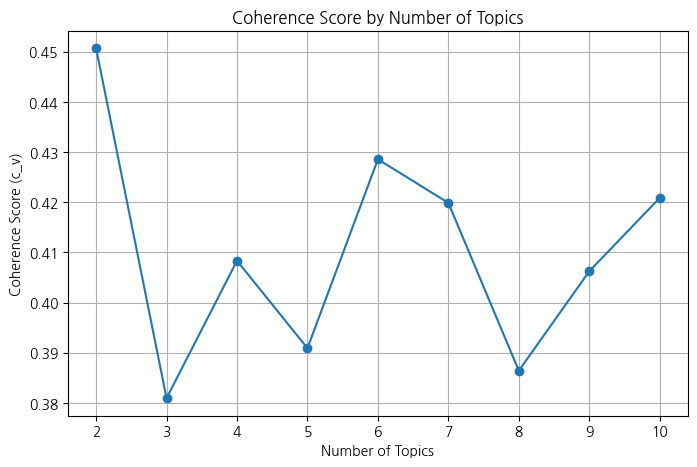

In [ ]:
import matplotlib.pyplot as plt
from gensim.models import LdaModel
from gensim.models import CoherenceModel
from tqdm import tqdm

# 1. 텍스트 정제 (tokens 리스트 만들기)
# 예: extract_nouns 함수 이용
texts = topic_df['topic_text'].dropna().map(extract_nouns).tolist()

# 2. dictionary, corpus 생성
from gensim.corpora import Dictionary
dictionary = Dictionary(texts)
corpus = [dictionary.doc2bow(text) for text in texts]

# 함수 정의
def compute_coherence_scores(dictionary, corpus, texts, start, limit, step):
    coherence_scores = []
    topic_range = range(start, limit, step)

    for num_topics in tqdm(topic_range):
        model = LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics,
                         random_state=42, passes=10, iterations=100)
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence = coherence_model.get_coherence()
        coherence_scores.append(coherence)
        print(f"num_topics = {num_topics}, coherence = {coherence:.4f}")

    return list(topic_range), coherence_scores

# 실행
x, y = compute_coherence_scores(dictionary, corpus, texts, start=2, limit=11, step=1)

# 그래프 출력
plt.figure(figsize=(8, 5))
plt.plot(x, y, marker='o')
plt.title('Coherence Score by Number of Topics')
plt.xlabel('Number of Topics')
plt.ylabel('Coherence Score (c_v)')
plt.xticks(x)
plt.grid(True)
plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 1. 빈 텍스트 제거
topic_df = topic_df.dropna(subset=['topic_text'])
topic_df = topic_df[topic_df['topic_text'].str.strip().astype(bool)]

# 2. CountVectorizer: BoW 벡터화
vectorizer = CountVectorizer(max_df=0.95, min_df=2, stop_words=stopwords)
X = vectorizer.fit_transform(topic_df['topic_text'])

# 3. LDA 학습 (토픽 수는 필요에 따라 조정)
lda = LatentDirichletAllocation(n_components=6, random_state=42)
lda.fit(X)

# 4. 토픽별 주요 키워드 출력
words = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [words[j] for j in topic.argsort()[:-7:-1]]
    print(f"📌 토픽 {i}: {' '.join(top_words)}")

# 5. 각 문서의 dominant topic 할당
topic_df['dominant_topic'] = lda.transform(X).argmax(axis=1)

| 토픽 번호 | 주요 키워드                 | 해석 (주제)               |
| ----- | ---------------------- | --------------------- |
| 토픽 0  | 면접, 인턴, 서류, 전공, 사람, 삼성 | 대기업 인턴·서류·전공 전략 고민    |
| 토픽 1  | 면접, 직무, 회사, 정도, 지원, 신입 | 신입 면접 실전 준비와 자기 수준 고민 |
| 토픽 2  | 인턴, 취업, 준비, 고민, 공부, 경험 | 비교과 활동, 공부 병행, 멘탈 이슈  |
| 토픽 3  | 채용, 개발, 취업, 한화, 기업, 면접 | 개발 계열 채용, IT 직무 준비 흐름 |
| 토픽 4  | 서류, 적성, 생각, 취업, 기업, 삼전 | 삼성계열 서류전형, GSAT 중심 고민 |


| 토픽 번호 | 정책 제안                                 |
| ----- | ------------------------------------- |
| 0     | 전공별 직무 매칭 설명회, 자기소개서 전공 사례 공유 프로그램    |
| 1     | AI 면접 모의시스템 + 피드백 연계 스터디 매칭 서비스       |
| 2     | 비교과 경험 vs 학점 전략 컨설팅, 취업 멘탈관리 그룹 상담 운영 |
| 3     | 개발 직무 대비 실습형 프로젝트·캡스톤디자인 연계 취업과정      |
| 4     | 삼성형 적성검사 특화 교육, 기출 기반 실전 시뮬레이션 제공     |


In [ ]:
#토픽별 문서 수
plt.figure(figsize=(8, 5))
sns.countplot(data=topic_df, x='dominant_topic', palette='Set2')
plt.title('토픽별 문서 수')
plt.xlabel('토픽')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()

#시간대별 토픽 빈도
hour_topic = topic_df.pivot_table(index='hour', columns='dominant_topic', aggfunc='size', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(hour_topic, cmap='YlGnBu', annot=True, fmt='d')
plt.title('시간대별 토픽 등장')
plt.xlabel('토픽')
plt.ylabel('시간대')
plt.tight_layout()
plt.show()

#요일별 토픽 빈도
topic_df['weekday'] = pd.to_datetime(topic_df['parsed_date']).dt.dayofweek
weekday_labels = ['월', '화', '수', '목', '금', '토', '일']
topic_df['weekday'] = topic_df['weekday'].map(dict(zip(range(7), weekday_labels)))
weekday_topic = topic_df.pivot_table(index='weekday', columns='dominant_topic', aggfunc='size', fill_value=0)
weekday_topic = weekday_topic.reindex(['월', '화', '수', '목', '금', '토', '일'])  # 순서 정렬
plt.figure(figsize=(10, 5))
sns.heatmap(weekday_topic, annot=True, fmt='d', cmap='YlOrRd')
plt.title('요일별 토픽 분포')
plt.xlabel('토픽')
plt.ylabel('요일')
plt.tight_layout()
plt.show()

#월별 토픽 변화
monthly_topic = topic_df.groupby(['month', 'dominant_topic']).size().unstack(fill_value=0)
monthly_topic.plot(marker='o', figsize=(10, 5))
plt.title('월별 토픽별 문서 수')
plt.xlabel('월')
plt.ylabel('문서 수')
plt.grid(True)
plt.tight_layout()
plt.show()

#토픽별 글 길이 분포
topic_df['text_length'] = topic_df['topic_text'].apply(len)

plt.figure(figsize=(8, 5))
sns.boxplot(data=topic_df, x='dominant_topic', y='text_length', palette='Set3')
plt.title('토픽별 글 길이')
plt.xlabel('토픽')
plt.ylabel('글 길이 (문자 수)')
plt.tight_layout()
plt.show()

| 분석 항목          | 주요 결과 요약                                               |
| -------------- | ------------------------------------------------------ |
| **토픽별 문서 수**   | 토픽 0(서류/전공), 토픽 1(면접/직무), 토픽 2(공부/고민)이 압도적으로 많음        |
| **시간대별 토픽 분포** | 오후 17시\~21시 사이 게시글 집중, 특히 토픽 0·1·2는 강의 후 저녁 시간대에 활발    |
| **요일별 토픽 분포**  | 월\~금에 글 집중, 주말엔 토픽 2(멘탈·준비 고민)만 일정량 유지 → 멘탈 지속성 보여줌    |
| **월별 토픽 변화**   | 4월에 모든 토픽 증가 → 인턴/공채 시즌 영향 추정 가능                       |
| **토픽별 글 길이**   | 토픽 2 글이 가장 길고, 토픽 3·4는 짧음 → 고민형(감정글) vs 정보형(단문글) 차이 명확 |


| 토픽 번호 | 주제 요약       | 특이 사항                      |
| ----- | ----------- | -------------------------- |
| 토픽 0  | 서류, 전공, 인턴  | 가장 많이 언급됨, 대기업 취업 준비 흐름 반영 |
| 토픽 1  | 면접, 직무, 신입  | 실전준비, 부족감 고민 글 많음          |
| 토픽 2  | 공부, 멘탈, 비교과 | 글 길이 길고, 감정 중심 글 다수        |
| 토픽 3  | 채용, 개발, 기업  | IT/개발 직군 관련 직무 집중형         |
| 토픽 4  | 삼성, 적성, 서류  | 특정 기업 중심, 단문성 글 많음         |


## EDA

### 토픽 별 키워드 워드 클라우드

In [ ]:
from wordcloud import WordCloud

In [ ]:
okt = Okt()

def extract_nouns(texts):
    nouns = []
    for text in texts:
        if isinstance(text, str):
            nouns += okt.nouns(text)
    return [n for n in nouns if len(n) > 1]  # 한 글자 제외

In [ ]:
from collections import Counter

# 토픽 개수 파악 (예: 0~4)
num_topics = topic_df['dominant_topic'].nunique()

for topic_num in range(num_topics):
    # 해당 토픽 글 모으기
    topic_texts = topic_df[topic_df['dominant_topic'] == topic_num]['topic_text']

    # 명사만 추출
    nouns = extract_nouns(topic_texts)

    # 빈도수 계산
    noun_freq = Counter(nouns)

    # 워드클라우드 생성
    wc = WordCloud(
        font_path='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',  # 한글 폰트
        background_color='white',
        width=800,
        height=400
    ).generate_from_frequencies(noun_freq)

    # 시각화
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Topic {topic_num} 워드클라우드')
    plt.show()


### 댓글 수와 추천 수의 상관관계

## 가설 설정 및 검정

### 가설 1. 요일별로 토픽 분포가 다르다

In [ ]:
from scipy.stats import chi2_contingency

# 교차표 생성
contingency_table = pd.crosstab(topic_df['weekday'], topic_df['dominant_topic'])

print("요일별 토픽 분포:")
print(contingency_table)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\n[카이제곱 독립성 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대빈도]")
expected_df = pd.DataFrame(expected, index=contingency_table.index, columns=contingency_table.columns)
print(expected_df)

# 시각화 (heatmap)
plt.figure(figsize=(10, 5))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap='YlGnBu')
plt.title('요일별 토픽 분포 (Observed)')
plt.xlabel('토픽')
plt.ylabel('요일')
plt.tight_layout()
plt.show()


- p > 0.05
- 요일에 따라 토픽 분포는 다르지 않다

### 가설 2. 월별로 토픽 분포가 다르다

In [ ]:
# 월별-토픽 교차표 생성
monthly_topic_ct = pd.crosstab(topic_df['month'], topic_df['dominant_topic'])

print("월별 토픽 분포:")
print(monthly_topic_ct)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(monthly_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
expected_df = pd.DataFrame(expected, index=monthly_topic_ct.index, columns=monthly_topic_ct.columns)
print(expected_df)

# 시각화
plt.figure(figsize=(10, 5))
sns.heatmap(monthly_topic_ct, annot=True, fmt='d', cmap='YlOrRd')
plt.title('월별 토픽 분포 Heatmap')
plt.xlabel('토픽 번호')
plt.ylabel('월')
plt.tight_layout()
plt.show()


- p < 0.05
- 월에 따라 토픽 분포는 통계적으로 유의미하게 다르다

In [ ]:
!pip install wordcloud
!apt-get -qq install fonts-nanum

In [ ]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 나눔고딕 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
plt.rc('font', family='NanumGothic')

In [ ]:
# 명사 추출 함수 생성
from konlpy.tag import Okt
okt = Okt()

def extract_nouns(text):
    return [noun for noun in okt.nouns(text) if len(noun) > 1]

In [ ]:
from wordcloud import WordCloud

top_topic_by_month = topic_df.groupby('month')['dominant_topic'].agg(lambda x: x.value_counts().idxmax())

for month, top_topic in top_topic_by_month.items():
    # 해당 월 & 최빈 토픽 필터링
    filtered_texts = topic_df[(topic_df['month'] == month) & (topic_df['dominant_topic'] == top_topic)]['topic_text']

    # 명사 추출
    noun_list = []
    for text in filtered_texts:
        noun_list.extend(extract_nouns(text))

    # 리스트를 문자열로 결합
    combined_nouns = ' '.join(noun_list)

    custom_stopwords = set([
    '것', '수', '등', '더', '의', '이런', '저런', '그런', '이렇게', '저렇게', '같이', '근데',
    '그래서', '그러면', '그런데', '하면', '해서', '되다', '하다', '되는데', '했는데', '하니까',
    '던데', '하더라', '같다', '보니까', '생각', '느낌', '정도', '약간', '진짜', '너무',
    '조금', '그냥', '걸', '때', '좀', '안', '거', '건', '게', '냐', '죠', '음', '아', '어'
])


    # 워드클라우드 생성
    wordcloud = WordCloud(
        font_path=font_path,
        background_color='white',
        width=800,
        height=400,
        stopwords=custom_stopwords
    ).generate(combined_nouns)

    # 시각화
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'{month}월 | 최빈 토픽 {top_topic} 명사 기반 워드클라우드')
    plt.tight_layout()
    plt.show()


명사만 추출해서 월별 최빈 토픽으로 워드클라우드 만들어보앗어요 일단.........

### 가설 3. 시간대별로 토픽 분포가 다르다

In [ ]:
# 시간대 구간 나누기
bins = [0, 6, 12, 18, 24]
labels = ['야간', '오전', '오후', '저녁']
topic_df['time_bin'] = pd.cut(topic_df['hour'], bins=bins, labels=labels, right=False)

# 시간대별 토픽 분포 교차표 만들기
time_topic_ct = pd.crosstab(topic_df['time_bin'], topic_df['dominant_topic'])
print("📊 [교차표] 시간대별 토픽 분포:")
print(time_topic_ct)

# 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(time_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
print(pd.DataFrame(expected, index=time_topic_ct.index, columns=time_topic_ct.columns))

# 시각화
plt.figure(figsize=(10, 5))
sns.heatmap(time_topic_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('시간대별 토픽 분포 Heatmap')
plt.xlabel('토픽 번호')
plt.ylabel('시간대')
plt.tight_layout()
plt.show()

- p < 0.05
- 시간대에 따라 토픽 분포에는 유의미한 차이가 있다
(시간대는 일단 임의로 나눔)

### 가설 4. 토픽 별 문서 수에 차이가 있다

In [ ]:
from scipy.stats import chisquare

# 토픽별 문서 수 카운트
topic_counts = topic_df['dominant_topic'].value_counts().sort_index()
observed = topic_counts.values

# 기대값: 모든 토픽이 균등하게 분포한다고 가정
expected = [len(topic_df) / len(topic_counts)] * len(topic_counts)

# 카이제곱 적합도 검정
chi2_stat, p_value = chisquare(f_obs=observed, f_exp=expected)

# 결과 출력
print("[카이제곱 적합도 검정 결과]")
print(f"Chi-squared 통계량: {chi2_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# 시각화
plt.figure(figsize=(7, 4))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='pastel')
plt.title('토픽별 문서 수 분포')
plt.xlabel('dominant_topic')
plt.ylabel('문서 수')
plt.tight_layout()
plt.show()


- p < 0.05
- 토픽별 문서 수에는 유의미한 차이가 있다

### 가설 5. 토픽 별 글 길이에는 차이가 있다

In [ ]:
# topic_text의 글자 수 기준 글 길이 컬럼 추가
topic_df['text_length'] = topic_df['topic_text'].str.len()

2. 등분산성 검정부터...
(평균 비교라 정규화는 따로 안햇더요)

In [ ]:
from scipy.stats import levene, shapiro

# 등분산 검정 (Levene's test)
levene(*[group['text_length'] for _, group in topic_df.groupby('dominant_topic')])

In [ ]:
!pip install pingouin

In [ ]:
import pingouin as pg

# Welch's ANOVA
welch_result = pg.welch_anova(dv='text_length', between='dominant_topic', data=topic_df)

print("Welch ANOVA 결과")
print(welch_result)

- p-unc < 0.05
- np2 = 0.066 -> 약간 낮은 중간 효과
- 토픽에 따른 글 길이에는 유의미한 차이가 있다

In [ ]:
pg.pairwise_gameshowell(dv='text_length', between='dominant_topic', data=topic_df)

- 유의미한 차이 없는 쌍: 0-4, 2-3
- 토픽 2, 3이 다른 토픽에 비해 유의미하게 글이 길고 토픽 0, 4는 다른 토픽에 비해 유의미하게 글이 짧다

### 가설 6. 추천수에 따라 토픽의 차이가 있다.

In [ ]:
from scipy.stats import chi2_contingency

# 1. 추천 수 기준 이진 변수 생성 (예: 평균 이상 vs 미만)
threshold = df['like'].mean()
topic_df['like_level'] = df['like'] >= threshold

# 2. 교차표 생성 (추천수 수준 vs 토픽)
like_topic_ct = pd.crosstab(topic_df['like_level'], topic_df['dominant_topic'])

print("추천수 수준에 따른 토픽 분포:")
print(like_topic_ct)

# 3. 카이제곱 독립성 검정
chi2, p, dof, expected = chi2_contingency(like_topic_ct)

print(f"\n[카이제곱 검정 결과]")
print(f"Chi-squared 통계량: {chi2:.4f}")
print(f"p-value: {p:.4f}")
print(f"자유도: {dof}")
print("\n[기대 빈도]")
expected_df = pd.DataFrame(expected, index=like_topic_ct.index, columns=like_topic_ct.columns)
print(expected_df)

# 4. 시각화
plt.figure(figsize=(8, 4))
sns.heatmap(like_topic_ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('추천수 수준에 따른 토픽 분포 (Observed)')
plt.xlabel('토픽 번호')
plt.ylabel('추천수 수준 (True=높음)')
plt.tight_layout()
plt.show()



- p-value: 0.0647
(신뢰수준 95% 하에서는 귀무가설을 기각할 수 없지만 인간행동 분석임을 고려해서 신뢰수준 90%하에서 해석을 진행해보자면,,,)

토픽 3이 다른 토픽에 비해 기대빈도와 관측빈도의 차이가 큼
-> 개발 계열 채용, IT 직무 준비 흐름 등의 내용이 다른 이용자에게 정보성 글 역할을 하였을 것


## 감정 모델링

### 데이터 로드

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data/everytime_df.csv', encoding='utf-8-sig')
df.head()

,content,comment,like,comment_count,scrap,date,parsed_date,year,month,day,hour,clean_text,morphs,tokens,processed,emotion_text,topic_text
0,지사트 결과 예상 발표일이 언제쯤인가요??,[],0,0,0,2분 전,2025-05-03 13:12:17.805464,2025,5,3,13,지사트 결과 예상 발표일이 언제쯤인가요,"['지사', '트', '결과', '예상', '발표', '일', '이', '언제', ...","['지사', '결과', '예상', '발표', '언제', '인가요']",지사 결과 예상 발표 언제 인가요,지사트 결과 예상 발표일이 언제쯤인가요??,지사 결과 예상 발표 언제 인가요
1,추천채용 지원현황에 추천이라뜨면 추천된건가요?\n그리고 서류전형만 우대인건지도 궁금...,[],0,0,0,39분 전,2025-05-03 12:35:17.805499,2025,5,3,12,추천채용 지원현황에 추천이라뜨면 추천된건가요 그리고 서류전형만 우대인건지도 궁금합니...,"['추천', '채용', '지원', '현황', '에', '추천', '이', '라', ...","['추천', '채용', '지원', '현황', '추천', '추천', '건가요', '서...",추천 채용 지원 현황 추천 추천 건가요 서류 전형 우대 건지 궁금 합니다 처음 봐서...,추천채용 지원현황에 추천이라뜨면 추천된건가요? 그리고 서류전형만 우대인건지도 궁금합...,추천 채용 지원 현황 추천 추천 건가요 서류 전형 우대 건지 궁금 합니다 처음 봐서...
2,취준스터디 같이 할 사람 각잡고 취준하기엔 한계가 있다보니\n컴활자격증부터 취득하려...,['혼자하셈...'],0,1,0,05/01 19:29,2025-05-01 19:29:00.000000,2025,5,1,19,취준스터디 같이 할 사람 각잡고 취준하기엔 한계가 있다보니 컴활자격증부터 취득하려는...,"['취', '준', '스터디', '같이', '할', '사람', '각', '잡', '...","['스터디', '같이', '사람', '준하', '한계', '자격증', '취득', '...",스터디 같이 사람 준하 한계 자격증 취득 려는데 자격증 준비 같이 사람,취준스터디 같이 할 사람 각잡고 취준하기엔 한계가 있다보니 컴활자격증부터 취득하려는...,스터디 같이 사람 준하 한계 자격증 취득 려는데 자격증 준비 같이 사람
3,경영 21질문 재무 학회 하나하고 이제 인턴하려는데 이 루트 밟으면 취업 되는거 맞...,"['그냥 은행 갈만 할듯', '대기업이 훨씬 가기 어려움']",0,2,0,05/01 19:25,2025-05-01 19:25:00.000000,2025,5,1,19,경영 21질문 재무 학회 하나하고 이제 인턴하려는데 이 루트 밟으면 취업 되는거 맞...,"['경영', '21', '질문', '재무', '학회', '하나', '하고', '이제...","['경영', '21', '질문', '재무', '학회', '하나', '하고', '이제...",경영 21 질문 재무 학회 하나 하고 이제 인턴 려는데 루트 으면 취업 을까요 취업...,경영 21질문 재무 학회 하나하고 이제 인턴하려는데 이 루트 밟으면 취업 되는거 맞...,경영 질문 재무 학회 하나 하고 이제 인턴 려는데 루트 으면 취업 을까요 취업 난이...
4,"막학기인데 최종졸업 학부 성적 막학기고 아직 졸업 안했는데, 입사지원서에 최종졸업 ...",[],0,0,0,05/01 19:05,2025-05-01 19:05:00.000000,2025,5,1,19,막학기인데 최종졸업 학부 성적 막학기고 아직 졸업 안했는데 입사지원서에 최종졸업 학...,"['막', '학기', '인데', '최종', '졸업', '학부', '성적', '막',...","['학기', '인데', '최종', '졸업', '학부', '성적', '학기', '아직...",학기 인데 최종 졸업 학부 성적 학기 아직 졸업 는데 입사 지원서 최종 졸업 학부 ...,막학기인데 최종졸업 학부 성적 막학기고 아직 졸업 안했는데 입사지원서에 최종졸업 학...,학기 인데 최종 졸업 학부 성적 학기 아직 졸업 는데 입사 지원서 최종 졸업 학부 ...


In [ ]:
# 1. 라이브러리 설치 (처음 1번만 실행)
!pip install -U sentence-transformers

In [ ]:
# 2. 불러오기
from sentence_transformers import SentenceTransformer
import pandas as pd

# 3. 모델 불러오기
model = SentenceTransformer('jhgan/ko-sbert-nli')  # 한국어에 특화된 SBERT

# 5. 결측치 제거 (예외 방지)
df = df[df['emotion_text'].notnull()].reset_index(drop=True)

# 6. 임베딩 벡터 추출
df['embedding'] = df['emotion_text'].apply(lambda x: model.encode(x))

# 확인
print(df[['emotion_text', 'embedding']].head(3))

- 감정 분석은 텍스트에 등장하는 단어들을 통해 어떤 감정이 드러나는지 분석하는 기법
- 미리 정의된 감정 어휘 사전이 필요
- 감정 어휘 사전에 포함된 어휘가 텍스트에 얼마나 분포하는지에 따라 해당 텍스트의 감정이 좌우
- 토픽 모델링이 텍스트의 주제를 찾아낸다면, 감정 분석은 텍스트의 의견을 찾아냄
- 즉, 텍스트는 주제(토픽)와 의견(감정)의 결합으로 이뤄졌다고 볼 수 있음


- 파이썬으로 감정 분석하는 방법
  - 감정 어휘 사전을 이용한 감정 상태 분류
    - 미리 분류해둔 감정어 사전을 통해 분석하고자 하는 텍스트의 단어들을 사전에 기반해 분류하고, 그 감정가를 계산
    - 이 때 사용되는 감정어 사전에는 해당 감정에 해당되는 단어를 미리 정의해둬야 함
  - 기계학습을 이용한 감정 상태 분류
    - 분석 데이터의 일부를 훈련 데이터로 사용해 그로부터 텍스트의 감정 상태를 분류

### 감정 사전 준비

- 감정 사전 라이브러리 설치
- afinn은 영어에 대한 긍정, 부정에 대한 감정 사전을 제공

### 기계학습을 이용한 감정 분석

#### 한국어 자연어 처리 konlpy와 형태소 분석기 MeCab 설치
- 형태소 분석기 https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh

In [ ]:
!set -x \
&& pip install konlpy \
&& curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh

In [ ]:
!curl -s https://raw.githubusercontent.com/konlpy/konlpy/master/scripts/mecab.sh | bash

In [ ]:
import re
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from konlpy.tag import Mecab
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

### 감정 분석 모델 비교

In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification
# import torch, numpy as np

# # KoELECTRA NSMC 파인튜닝 모델 불러오기
# model_name = "monologg/koelectra-small-finetuned-nsmc"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name)

# # 예시 문장 입력
# text = "이 영화는 정말 재미있어요!"
# inputs = tokenizer(text, return_tensors="pt")
# outputs = model(**inputs)

# # Softmax로 확률 계산
# logits = outputs.logits               # 모델 출력 로짓 값
# probs = torch.nn.functional.softmax(logits, dim=1)[0]  # 소프트맥스 확률
# probs = probs.detach().numpy()        # numpy 배열로 변환

# # 예측 레이블 결정
# pred_label_idx = np.argmax(probs)     # 가장 높은 확률의 인덱스
# # 모델 config에 id2label 이 정의돼 있다면 사용, 없으면 직접 매핑
# label_map = model.config.id2label if model.config.id2label else {0: "NEG", 1: "POS"}
# pred_label = label_map[pred_label_idx]

# print(f"각 클래스 확률: {probs}")       # 예: [0.002, 0.998] 형태
# print(f"예측 감정: {pred_label}")      # 예: "POSITIVE" (긍정)

In [ ]:
# model_name = "alsgyu/sentiment-analysis-fine-tuned-model"
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModelForSequenceClassification.from_pretrained(model_name)

# text = "영화 내용이 평범했고 그럭저럭 볼 만했습니다."
# inputs = tokenizer(text, return_tensors="pt")
# outputs = model(**inputs)

# probs = torch.nn.functional.softmax(outputs.logits, dim=1)[0].tolist()  # 파이썬 리스트로 변환
# pred_idx = probs.index(max(probs))  # 최고 확률 인덱스

# # id2label이 정의되었다면 사용, 아니면 수동으로 매핑 가정
# label_map = model.config.id2label if model.config.id2label else {0: "부정", 1: "중립", 2: "긍정"}
# pred_label = label_map[pred_idx]

# print(f"확률 분포: {probs}")      # 예: [0.1, 0.7, 0.2] (부정, 중립, 긍정 확률)
# print(f"예측 감정: {pred_label}")  # 예: "중립"

In [ ]:
# from transformers import pipeline

# model_name = "tabularisai/multilingual-sentiment-analysis"
# clf = pipeline("text-classification", model=model_name, tokenizer=model_name)

# text = "이 제품은 가격 대비 품질이 훌륭하네요!"
# results = clf(text, return_all_scores=True)

# # 결과 출력
# for res in results[0]:
#     label = res['label']
#     score = res['score']
#     print(f"{label}: {score:.4f}")
# # 예시 출력 형태:
# # Very Negative: 0.0001
# # Negative: 0.0010
# # Neutral: 0.05
# # Positive: 0.20
# # Very Positive: 0.7489

# # 최종 예측 레이블 (스코어 최고값의 레이블)
# pred_label = max(results[0], key=lambda x: x['score'])['label']
# print("예측 감정:", pred_label)

In [ ]:
pip install transformers

In [ ]:
import pandas as pd
from transformers import pipeline


# 감정 분석 파이프라인 설정
model_name = "tabularisai/multilingual-sentiment-analysis"
classifier = pipeline("text-classification", model=model_name, tokenizer=model_name)

# 다국어 5단계 결과 → 3단계로 변환하는 함수
def map_sentiment_5_to_3(text):
    try:
        result = classifier(text, return_all_scores=True)[0]
        scores = {item['label']: item['score'] for item in result}
        # 가장 높은 점수 기준
        top_label = max(scores, key=scores.get)

        if top_label in ["Very Negative", "Negative"]:
            return "negative"
        elif top_label in ["Very Positive", "Positive"]:
            return "positive"
        else:
            return "neutral"
    except:
        return "neutral"  # 에러 발생 시 기본값

# 감정 분석 적용
df['emotion'] = df['emotion_text'].astype(str).apply(map_sentiment_5_to_3)

# 결과 확인
print(df[['emotion_text', 'emotion']].head())

# 저장
df.to_csv("everytime_with_emotion.csv", index=False)

In [ ]:
df = pd.read_csv("everytime_with_emotion.csv")
df.to_csv("everytime_with_emotion_utf8sig.csv", index=False, encoding='utf-8-sig')

In [ ]:
!pip install transformers pandas tqdm

import pandas as pd
from transformers import pipeline
from tqdm import tqdm
import time

# ✅ 1. 데이터 불러오기
df = df.dropna(subset=['emotion_text']).reset_index(drop=True)

# ✅ 2. 사용할 모델 정의 및 파이프라인 생성
models = {
    "multilingual": "tabularisai/multilingual-sentiment-analysis",
    "koelectra": "monologg/koelectra-small-finetuned-nsmc"
}

pipelines = {
    k: pipeline("text-classification", model=v, tokenizer=v)
    for k, v in models.items()
}

# ✅ 3. 매핑 함수 정의
def map_multilingual(output):
    label = output[0]['label']
    if label in ["Very Negative", "Negative"]:
        return "negative"
    elif label in ["Very Positive", "Positive"]:
        return "positive"
    else:
        return "neutral"

def map_koelectra(output):
    label = output[0]['label'].lower()
    return "positive" if label == "positive" else "negative"  # koelectra는 중립 없음

# ✅ 4. 감정 분석 수행
results = {k: [] for k in models}
for text in tqdm(df['emotion_text'].astype(str), desc="감정 분석 중"):
    for k in models:
        try:
            output = pipelines[k](text, truncation=True)
            if k == "multilingual":
                results[k].append(map_multilingual(output))
            else:
                results[k].append(map_koelectra(output))
        except:
            results[k].append("error")
    time.sleep(0.02)  # 너무 빠르게 돌리지 않기

# ✅ 5. 결과 반영
for k in models:
    df[f"pred_{k}"] = results[k]

# ✅ 6. 최종 결정 (일치 시 확정, 불일치 시 manual)
def decide_final(row):
    preds = [row[f"pred_{k}"] for k in models]
    return preds[0] if all(p == preds[0] for p in preds) else "manual"

df['final_emotion'] = df.apply(decide_final, axis=1)

# ✅ 7. 저장
df.to_csv("everytime_with_emotion_final.csv", index=False)
manual_df = df[df['final_emotion'] == "manual"]
manual_df.to_csv("manual_review_needed.csv", index=False)

print("✅ 감정 분석 완료! 결과 저장됨:")
print("- 전체 결과: everytime_with_emotion_final.csv")
print("- 수작업 필요한 문장: manual_review_needed.csv")

In [ ]:
df = pd.read_csv("everytime_with_emotion_final.csv")
df.to_csv("everytime_with_emotion_final_utf8sig.csv", index=False, encoding='utf-8-sig')

### TF-IDF

In [ ]:
# # ✅ 1. Hugging Face 라이브러리 설치
# !pip install transformers datasets accelerate -q
# !pip install sentencepiece -q

In [ ]:
# !pip install -q transformers datasets accelerate sentencepiece

In [ ]:
# from google.colab import files
# uploaded = files.upload()

In [ ]:
# # import os
# # os.environ["OPENBLAS_NUM_THREADS"] = "1"

# # import pandas as pd
# # from sklearn.feature_extraction.text import TfidfVectorizer
# # from sklearn.linear_model import LogisticRegression
# # from sklearn.model_selection import train_test_split
# from sklearn.metrics import classification_report

# # 데이터 불러오기
# df = pd.read_csv('/content/drive/MyDrive/data/everytime_with_emotion_final_utf8sig.csv')

# # 레이블 필터링
# df = df[df['emotion'].isin(['positive', 'neutral', 'negative'])].copy()
# df.dropna(subset=['emotion_text'], inplace=True)

# # 샘플링
# df_sampled = df.sample(n=500, random_state=42)

# # 벡터화
# vectorizer = TfidfVectorizer(max_features=3000)
# X = vectorizer.fit_transform(df_sampled['emotion_text'])

# # 레이블 인코딩
# label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
# y = df_sampled['emotion'].map(label_map)

# # 학습-테스트 분할
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 모델 학습
# model = LogisticRegression(max_iter=500)
# model.fit(X_train, y_train)

# # 평가
# y_pred = model.predict(X_test)
# print(classification_report(y_test, y_pred, target_names=label_map.keys()))

지금처럼 감정 nuance가 필요한 문장은 context 이해가 중요

단어만 보고 판단하는 TF-IDF는 한계가 있음

➤ KoBERT, KcELECTRA 같은 BERT 계열로 바꾸면 성능 급상승 가능

### KoBERT

In [ ]:
!pip install transformers datasets accelerate sentencepiece -q

In [ ]:
import transformers
print(transformers.__version__)  # 4.51.3 확인
from transformers import TrainingArguments, Trainer

In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
# 데이터셋 전처리
import pandas as pd
from datasets import Dataset

# 감정 레이블 필터링
df = df[df['final_emotion'].isin(["positive", "neutral", "negative"])].copy()
df.dropna(subset=["emotion_text"], inplace=True)

# 레이블 숫자로 변환
label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["final_emotion"].map(label_map)

# HuggingFace Dataset으로 변환
dataset = Dataset.from_pandas(df[["emotion_text", "label"]])
dataset = dataset.train_test_split(test_size=0.2, seed=42)

rev_label_map = {v: k for k, v in label_map.items()}

In [ ]:
# KoBERT 모델 로딩 및 토큰화
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("monologg/kobert")

def tokenize(batch):
    return tokenizer(batch["emotion_text"], padding="max_length", truncation=True, max_length=128)

tokenized_dataset = dataset.map(tokenize, batched=True)

In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True
)

In [ ]:
training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    do_eval=True,
    do_train=True
)

In [ ]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

model = AutoModelForSequenceClassification.from_pretrained("monologg/kobert", num_labels=3)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./kobert_emotion",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    logging_dir="./logs",
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

trainer.train()

### KoBERT-like 모델
- KoBERT 구조가 복잡해서 Trainer로 잘 안 돌아가서
아예 HuggingFace에서 Trainer 완전 호환되는 KoBERT-like 모델로 전환..

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")
model = AutoModelForSequenceClassification.from_pretrained("skt/kobert-base-v1", num_labels=3)

In [ ]:
!pip install --upgrade transformers

In [ ]:
!pip install datasets
!pip install scikit-learn
!pip install accelerate

In [ ]:
import pandas as pd

# 업로드한 CSV 파일 경로에 맞춰 수정
# df = pd.read_csv('/content/everytime_with_emotion_final_utf8sig.csv', encoding='utf-8-sig')
df = df[['emotion_text', 'emotion']]  # 필요한 열만 사용
df = df.dropna()

# 레이블 인코딩
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['emotion'].map(label_map)

# 훈련/검증 데이터 나누기
from sklearn.model_selection import train_test_split

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['emotion_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")

# 토큰화
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=128)
val_encodings = tokenizer(val_texts, truncation=True, padding=True, max_length=128)

# HuggingFace Dataset 객체로 변환
import torch

class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_encodings, train_labels)
val_dataset = EmotionDataset(val_encodings, val_labels)

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
# df = pd.read_csv("/content/everytime_with_emotion_final_utf8sig.csv", encoding="utf-8-sig")
df = df[['emotion_text', 'emotion']].dropna()

label_map = {"negative": 0, "neutral": 1, "positive": 2}
df["label"] = df["emotion"].map(label_map)

train_texts, val_texts, train_labels, val_labels = train_test_split(
    df["emotion_text"].tolist(), df["label"].tolist(), test_size=0.2, random_state=42
)

tokenizer = AutoTokenizer.from_pretrained("skt/kobert-base-v1")
model = AutoModelForSequenceClassification.from_pretrained("skt/kobert-base-v1", num_labels=3).to(device)

# Dataset 정의
class EmotionDataset(Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("beomi/kcbert-base")
model = AutoModelForSequenceClassification.from_pretrained("beomi/kcbert-base", num_labels=3).to(device)

In [ ]:
class EmotionDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'  # 이게 핵심입니다
        )
        self.labels = labels

    def __getitem__(self, idx):
        return {
            'input_ids': self.encodings['input_ids'][idx],
            'attention_mask': self.encodings['attention_mask'][idx],
            'labels': torch.tensor(self.labels[idx])
        }

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = EmotionDataset(train_texts, train_labels)
val_dataset = EmotionDataset(val_texts, val_labels)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [ ]:
from torch import nn, optim
from tqdm import tqdm

optimizer = optim.AdamW(model.parameters(), lr=5e-5)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):  # 원하는 epoch 수만큼 반복
    model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}")
    for batch in loop:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        loop.set_postfix(loss=loss.item())

    print(f"✅ Epoch {epoch+1} complete. Avg Loss: {total_loss / len(train_loader):.4f}")

In [ ]:
# 모델 저장
model.save_pretrained("/content/my_kobert_emotion_model")
tokenizer.save_pretrained("/content/my_kobert_emotion_model")

print("✅ 모델 저장 완료!")

In [ ]:
# 모델 및 토크나이저 다시 불러오기
#from transformers import AutoTokenizer, AutoModelForSequenceClassification

#tokenizer = AutoTokenizer.from_pretrained("/content/my_kobert_emotion_model")
#model = AutoModelForSequenceClassification.from_pretrained("/content/my_kobert_emotion_model").to(device)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
        labels = batch["labels"].cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels)

print(classification_report(all_labels, all_preds, target_names=["negative", "neutral", "positive"]))

## beomi/kcbert-large 모델

In [ ]:
# 데이터 로드
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data/everytime_df.csv', encoding='utf-8-sig')
df.head()

,content,comment,like,comment_count,scrap,date,parsed_date,year,month,day,hour,clean_text,morphs,tokens,processed,emotion_text,topic_text
0,시즌 끝났네… 이걸 또 하라고….?ㅠ,"['졸유함?', '졸유? 졸유는 했지 이미 없었지만', '이번에 한번 더 늘릴거냐'...",11,6,0,05/04 20:39,2025-05-04 20:39:00,2025.0,5.0,4.0,20.0,시즌 끝났네 이걸 또 하라고,"['시즌', '끝', '났', '네', '이걸', '또', '하', '라고']","['시즌', '이걸', '라고']",시즌 이걸 라고,시즌 끝났네 이걸 또 하라고 .?ㅠ 졸 유 함 ? 졸 유 ? 졸 유 는 했 지 이 ...,시즌 이걸 라고
1,면준 다들 면접준비 얼마나 하시나요,"['프리스타일', '저 중요한곳 할 때는 2주 넘게 햇어요', '면준은 서류 합격 ...",0,7,0,05/04 19:16,2025-05-04 19:16:00,2025.0,5.0,4.0,19.0,면준 다들 면접준비 얼마나 하시나요,"['면', '준', '다', '들', '면접', '준비', '얼마나', '하', '...","['면접', '준비', '얼마나', '나요']",면접 준비 얼마나 나요,면준 다들 면접준비 얼마나 하시나요 프 리 스 타 일 저 중 요 한 곳 할 때 는 ...,면접 준비 나요
2,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나,"['나같은애도 합하더라 포기하지마', '이 말 한 줄에 토익 100점 오른 기분이에...",1,7,0,05/04 18:25,2025-05-04 18:25:00,2025.0,5.0,4.0,18.0,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나,"['최종', '합격', '후기', '찾아보', '면', '다', '들', '너무',...","['최종', '합격', '후기', '찾아보', '너무', '반짝', '반짝', '빛...",최종 합격 후기 찾아보 너무 반짝 반짝 빛난다 저렇게 니깐 합격 는구나,최종합격 후기 찾아보면 다들 너무 반짝 반짝 빛난다 저렇게 사니깐 합격하는구나 나 ...,최종 합격 후기 찾아보 너무 반짝 반짝 빛난다 저렇게 니깐 합격 는구나
3,cj 인적성 Cj 인적성 단계에서 100% 인적성 점수만 가지고 컷하나요..? 아님...,"['그걸 누가 알까요', 'CJ 할애비도 모름', 'CJ 할애비는 알고 있을 것 같...",0,7,0,05/04 14:39,2025-05-04 14:39:00,2025.0,5.0,4.0,14.0,cj 인적성 Cj 인적성 단계에서 100 인적성 점수만 가지고 컷하나요 아님 서류도...,"['cj', '인', '적성', 'Cj', '인', '적성', '단계', '에서',...","['cj', '적성', 'Cj', '적성', '단계', '100', '인적', '점...",cj 적성 Cj 적성 단계 100 인적 점수 가지 나요 아님 서류 다시 볼까요,cj 인적성 Cj 인적성 단계에서 100 인적성 점수만 가지고 컷하나요..? 아님 ...,인적 적성 단계 적성 점수 가지 나요 아님 서류 다시 볼까요
4,선배님들~! 설문조사 참여 부탁드립니다! 안녕하세요!\n중앙대학교 경영경제대학 학술...,[],4,0,0,05/04 14:25,2025-05-04 14:25:00,2025.0,5.0,4.0,14.0,선배님들 설문조사 참여 부탁드립니다 안녕하세요 중앙대학교 경영경제대학 학술제에 참가...,"['선배', '님', '들', '설문', '조사', '참여', '부탁', '드립니다...","['선배', '설문', '조사', '참여', '부탁', '드립니다', '안녕', '...",선배 설문 조사 참여 부탁 드립니다 안녕 세요 중앙 대학교 경영 경제 대학 학술 참...,선배님들 ! 설문조사 참여 부탁드립니다! 안녕하세요! 중앙대학교 경영경제대학 학술제...,선배 설문 조사 참여 부탁 드립니다 안녕 세요 중앙 대학교 경영 경제 대학 학술 참...


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained("beomi/kcbert-large")
model = AutoModelForSequenceClassification.from_pretrained("beomi/kcbert-large", num_labels=3).to(device)

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/672 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/250k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at beomi/kcbert-large and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


NameError: name 'device' is not defined

### 전체 데이터셋 예측 적용

In [ ]:
from tqdm import tqdm

texts = df["emotion_text"].tolist()
batch_size = 32
predicted_labels = []

model.eval()

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(batch_texts, return_tensors="pt", padding="max_length", truncation=True, max_length=128)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        predicted_labels.extend(preds)

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["predicted_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
# 샘플링 후 직접 감정 수정
corrected_emotions = []

sample_df = df.sample(n=30).reset_index()

for i, row in sample_df.iterrows():
    print(f"\n[{i+1}] 문장: {row['emotion_text']}")
    print(f"   🤖 예측 감정: {row['predicted_emotion']}")

    while True:
        label = input("👉 감정 직접 입력 (positive / negative / neutral / enter: 예측 유지): ").strip().lower()
        if label == "":
            corrected_emotions.append(row['predicted_emotion'])  # 기존 예측 유지
            break
        elif label in ["positive", "negative", "neutral"]:
            corrected_emotions.append(label)
            break
        else:
            print("❗ 다시 입력해주세요.")

sample_df["corrected_emotion"] = corrected_emotions

In [ ]:
for i, row in sample_df.iterrows():
    df.loc[row['index'], "predicted_emotion"] = row["corrected_emotion"]

In [ ]:
df.to_csv("everytime_final_emotion.csv", index=False, encoding="utf-8-sig")

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["final_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
df.to_csv("everytime_with_final_emotion.csv", index=False, encoding="utf-8-sig")

In [ ]:
from google.colab import files
files.download("everytime_with_final_emotion.csv")

### 최종 데이터셋 적용

In [ ]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/data/everytime_df.csv', encoding='utf-8-sig')
df.head()

In [ ]:
from tqdm import tqdm
import torch

model.eval()
texts = df["emotion_text"].tolist()  # 예측 대상 열
batch_size = 32
predicted_labels = []

with torch.no_grad():
    for i in tqdm(range(0, len(texts), batch_size)):
        batch_texts = texts[i:i+batch_size]
        inputs = tokenizer(
            batch_texts, return_tensors="pt", padding="max_length",
            truncation=True, max_length=128
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}

        outputs = model(**inputs)
        preds = torch.argmax(outputs.logits, dim=1).cpu().tolist()
        predicted_labels.extend(preds)

In [ ]:
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df["final_emotion"] = [label_map[label] for label in predicted_labels]

In [ ]:
df.to_csv("everytime_with_final_emotion.csv", index=False, encoding="utf-8-sig")

# 다운로드 (Colab용)
from google.colab import files
files.download("everytime_with_final_emotion.csv")